Food delivery prediction through linear regression and logistic regression evaluation metrics through confusion meatrix and roc curve

In [140]:
import pandas as pd
path = "/content/Food_Delivery_Time_Prediction.csv"
data = pd.read_csv(path)

In [141]:
data.describe()

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11.498050,5.250000,3.738500,3.686500,70.494950,1046.488700,46.616650
std,6.841755,2.745027,0.703021,0.697063,29.830694,548.568922,29.361706
min,0.520000,1.000000,2.500000,2.600000,15.230000,122.300000,1.240000
25%,6.090000,3.000000,3.200000,3.100000,46.997500,553.270000,21.602500
50%,10.265000,5.000000,3.800000,3.700000,72.775000,1035.950000,47.530000
75%,16.497500,8.000000,4.300000,4.300000,96.650000,1543.125000,70.245000
max,24.900000,10.000000,5.000000,5.000000,119.670000,1997.420000,99.740000


In [142]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [143]:
data.describe()

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11.498050,5.250000,3.738500,3.686500,70.494950,1046.488700,46.616650
std,6.841755,2.745027,0.703021,0.697063,29.830694,548.568922,29.361706
min,0.520000,1.000000,2.500000,2.600000,15.230000,122.300000,1.240000
25%,6.090000,3.000000,3.200000,3.100000,46.997500,553.270000,21.602500
50%,10.265000,5.000000,3.800000,3.700000,72.775000,1035.950000,47.530000
75%,16.497500,8.000000,4.300000,4.300000,96.650000,1543.125000,70.245000
max,24.900000,10.000000,5.000000,5.000000,119.670000,1997.420000,99.740000


In [144]:
data.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


In [145]:
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [146]:
data = pd.get_dummies(data,columns=["Weather_Conditions","Traffic_Conditions","Order_Priority","Order_Time","Vehicle_Type"],dtype=int)

In [147]:
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,...,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,4,4.1,3.0,26.22,1321.10,81.54,...,0,0,1,1,0,0,0,0,0,1
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,8,4.5,4.2,62.61,152.21,29.02,...,0,1,0,0,0,0,1,0,0,1
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,9,3.3,3.4,48.43,1644.38,64.17,...,1,0,0,0,0,0,1,0,1,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,2,3.2,3.7,111.63,541.25,79.23,...,0,0,1,0,1,0,0,0,1,0
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,6,3.5,2.8,32.38,619.81,2.34,...,0,1,0,0,0,0,1,0,1,0


In [148]:
data = data.drop("Order_ID", axis=1)

In [149]:
x = data.drop("Delivery_Time", axis=1)
y = data["Delivery_Time"]

In [150]:
data.describe()

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,...,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000
mean,11.498050,5.250000,3.738500,3.686500,70.494950,1046.488700,46.616650,0.21000,0.285000,0.240000,...,0.290000,0.375000,0.335000,0.295000,0.285000,0.195000,0.22500,0.345000,0.345000,0.310000
std,6.841755,2.745027,0.703021,0.697063,29.830694,548.568922,29.361706,0.40833,0.452547,0.428155,...,0.454901,0.485338,0.473175,0.457187,0.452547,0.397195,0.41863,0.476561,0.476561,0.463654
min,0.520000,1.000000,2.500000,2.600000,15.230000,122.300000,1.240000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,6.090000,3.000000,3.200000,3.100000,46.997500,553.270000,21.602500,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,10.265000,5.000000,3.800000,3.700000,72.775000,1035.950000,47.530000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,16.497500,8.000000,4.300000,4.300000,96.650000,1543.125000,70.245000,0.00000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,1.000000,1.000000,1.000000
max,24.900000,10.000000,5.000000,5.000000,119.670000,1997.420000,99.740000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [151]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix["Delivery_Time"].sort_values(ascending=False)

,Delivery_Time
Delivery_Time,1.000000
Vehicle_Type_Bicycle,0.093194
Weather_Conditions_Rainy,0.054402
Traffic_Conditions_Low,0.039714
Order_Priority_Low,0.012849
Order_Time_Morning,0.011984
Traffic_Conditions_Medium,0.011810
Order_Time_Afternoon,0.006363
Order_Priority_High,0.004804
Vehicle_Type_Car,-0.001372


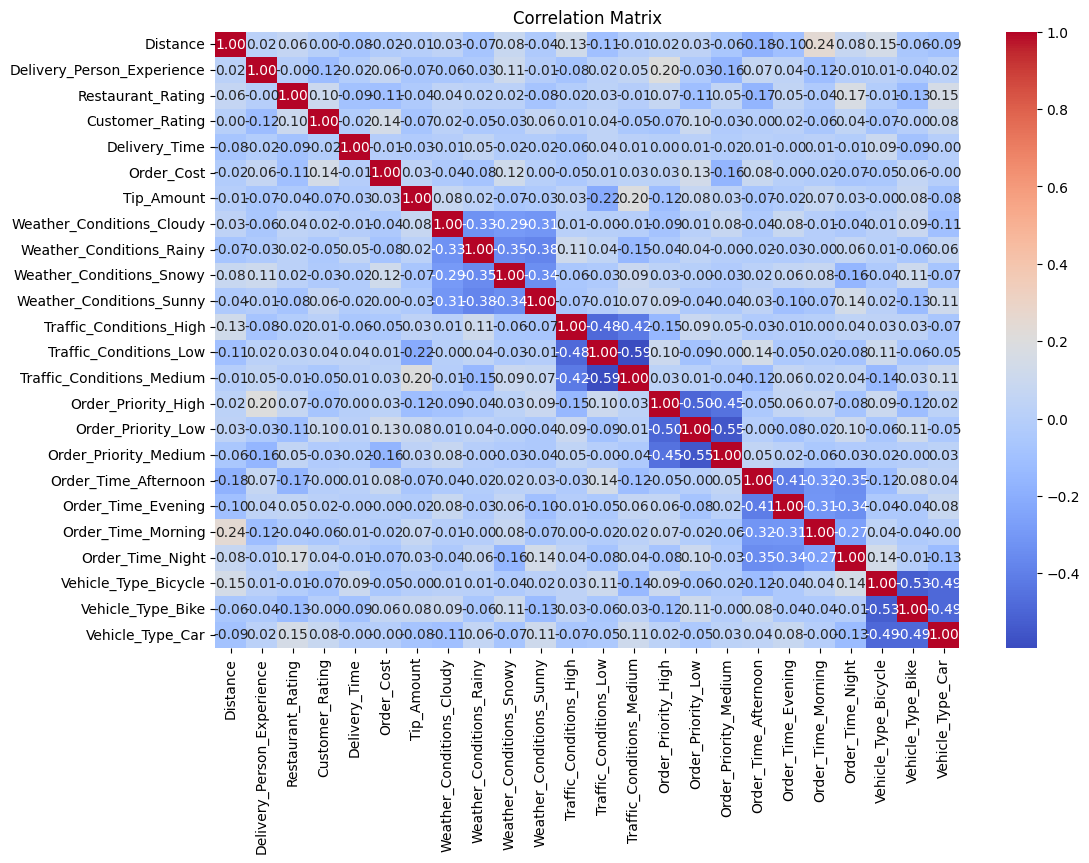

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

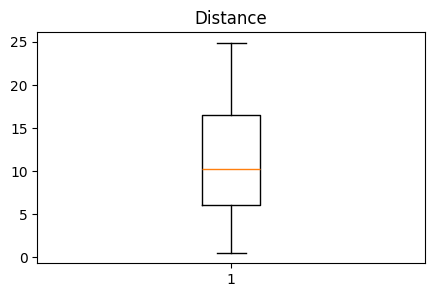

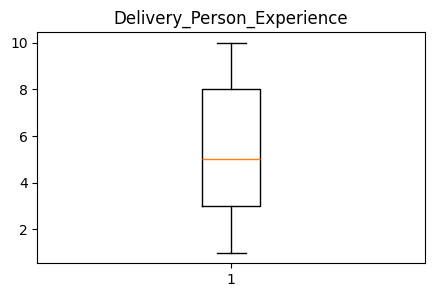

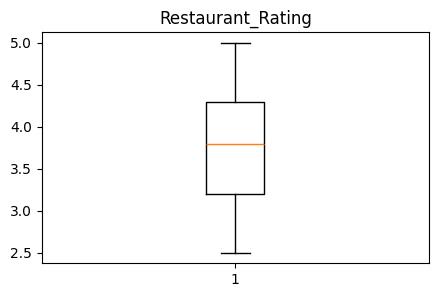

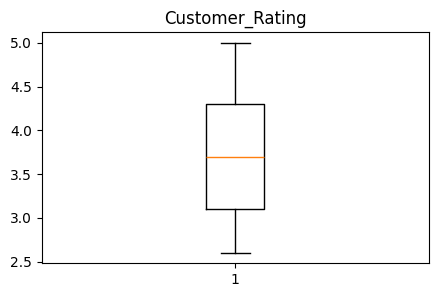

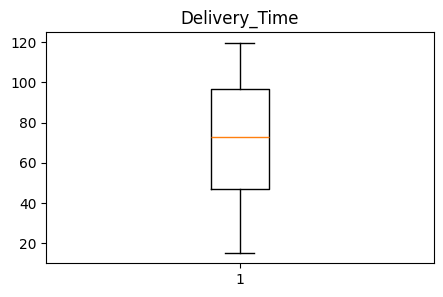

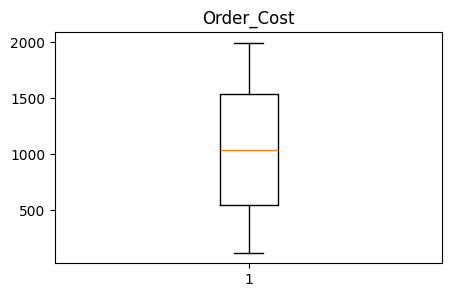

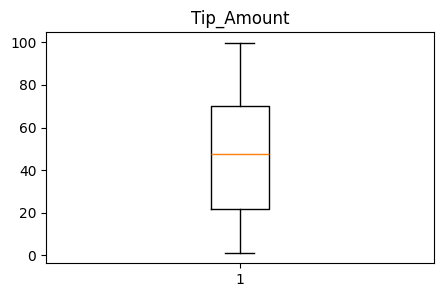

In [153]:
import matplotlib.pyplot as plt

num_cols = [
    "Distance",
    "Delivery_Person_Experience",
    "Restaurant_Rating",
    "Customer_Rating",
    "Delivery_Time",
    "Order_Cost",
    "Tip_Amount"
]

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(data[col])
    plt.title(col)
    plt.show()


In [154]:
num_cols = [
    "Distance",
    "Delivery_Person_Experience",
    "Restaurant_Rating",
    "Customer_Rating",
    "Delivery_Time",
    "Order_Cost",
    "Tip_Amount"
]

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]


In [155]:
data.head()

,Customer_Location,Restaurant_Location,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,...,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car
0,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,4,4.1,3.0,26.22,1321.10,81.54,0,...,0,0,1,1,0,0,0,0,0,1
1,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,8,4.5,4.2,62.61,152.21,29.02,1,...,0,1,0,0,0,0,1,0,0,1
2,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,9,3.3,3.4,48.43,1644.38,64.17,0,...,1,0,0,0,0,0,1,0,1,0
3,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,2,3.2,3.7,111.63,541.25,79.23,1,...,0,0,1,0,1,0,0,0,1,0
4,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,6,3.5,2.8,32.38,619.81,2.34,0,...,0,1,0,0,0,0,1,0,1,0


In [156]:


data["Rush_Hour"] = (
    data["Order_Time_Morning"] +
    data["Order_Time_Evening"]
).astype(int)
print(data[[
    "Order_Time_Morning",
    "Order_Time_Afternoon",
    "Order_Time_Evening",
    "Order_Time_Night",
    "Rush_Hour"
]].head())

   Order_Time_Morning  Order_Time_Afternoon  Order_Time_Evening  \
0                   0                     1                   0   
1                   0                     0                   0   
2                   0                     0                   0   
3                   0                     0                   1   
4                   0                     0                   0   

   Order_Time_Night  Rush_Hour  
0                 0          0  
1                 1          0  
2                 1          0  
3                 0          1  
4                 1          0  


In [157]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [158]:
X = data[["Distance","Traffic_Conditions_High","Traffic_Conditions_Low","Traffic_Conditions_Medium","Order_Priority_High","Order_Priority_Low","Order_Priority_Medium"]]
y = data["Delivery_Time"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [159]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [160]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 915.3719745504928
R-squared: 0.010292275231804426
Mean Absolute Error: 25.48472806891557


In [161]:
data["Delivery_Status"] = data["Delivery_Time"].apply(
    lambda x: 1 if x > 30 else 0
)

In [162]:
data = data.drop(columns = ["Customer_Location","Restaurant_Location"])

In [163]:
X = data.drop(columns=["Delivery_Status"])

y = data["Delivery_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [164]:
data.head()

,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,...,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Rush_Hour,Delivery_Status
0,1.57,4,4.1,3.0,26.22,1321.10,81.54,0,1,0,...,1,1,0,0,0,0,0,1,0,0
1,21.32,8,4.5,4.2,62.61,152.21,29.02,1,0,0,...,0,0,0,0,1,0,0,1,0,1
2,6.95,9,3.3,3.4,48.43,1644.38,64.17,0,0,1,...,0,0,0,0,1,0,1,0,0,1
3,13.79,2,3.2,3.7,111.63,541.25,79.23,1,0,0,...,1,0,1,0,0,0,1,0,1,1
4,6.72,6,3.5,2.8,32.38,619.81,2.34,0,1,0,...,0,0,0,0,1,0,1,0,0,1


In [165]:
modell = LogisticRegression(max_iter=1000)
modell.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [166]:
y_pred = modell.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.95
Precision: 0.9705882352941176
Recall: 0.9705882352941176
F1 Score: 0.9705882352941176
Confusion Matrix:
 [[ 5  1]
 [ 1 33]]


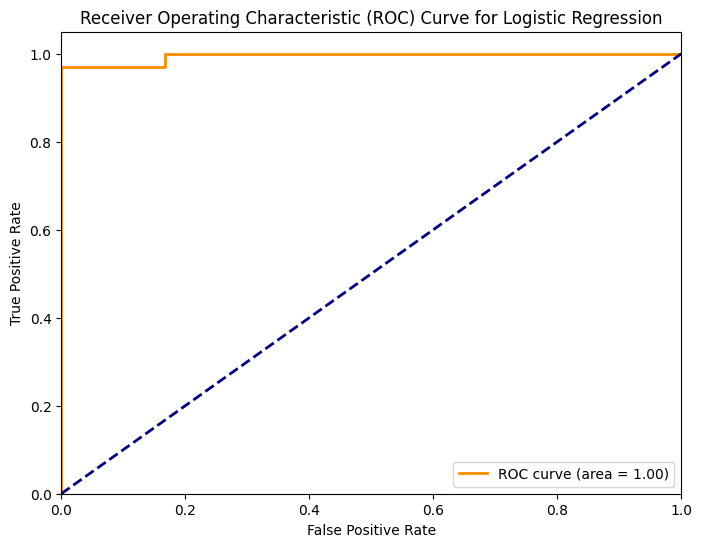

In [170]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_pred_proba = modell.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.show()